<a href="https://colab.research.google.com/github/siddhi-308-dotcom/ML/blob/main/EXP7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("diabetes.csv")

print("First 5 rows:\n", df.head())


First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [10]:
print("\nDataset Info:\n")
df.info()

print("\nMissing Values:\n", df.isnull().sum())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction  

In [12]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

print("\nAfter Handling Missing Values:\n", df.isnull().sum())



After Handling Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


/tmp/ipykernel_7487/3493398161.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [13]:
print("\nNo categorical variables to encode.")

# 🔹 Step 7: Descriptive Statistics
print("\nDescriptive Statistics:\n", df.describe())



No categorical variables to encode.

Descriptive Statistics:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.791221   86.383060   
min       0.000000   44.000000      24.000000       7.000000   14.000000   
25%       1.000000   99.750000      64.000000      25.000000  121.500000   
50%       3.000000  117.000000      72.000000      29.000000  125.000000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    32.455208                  0.471876   33.240885    0.348958  
std      6.875177                  0.33132

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

L2 regularization

In [16]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

L1 regularization

In [17]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

ElasticNet


In [18]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

elastic_pred = elastic.predict(X_test)

Evaluation


In [19]:
from sklearn.metrics import mean_squared_error

print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))
print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))
print("ElasticNet MSE:", mean_squared_error(y_test, elastic_pred))

Ridge MSE: 0.1647121358140127
Lasso MSE: 0.1783163609259055
ElasticNet MSE: 0.17014665967371836


Coefficient Comparison

In [20]:
import pandas as pd

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

print(coeff_df)

                    Feature     Ridge     Lasso  ElasticNet
0               Pregnancies  0.036922  0.000000    0.005709
1                   Glucose  0.191945  0.127498    0.149678
2             BloodPressure -0.022059  0.000000    0.000000
3             SkinThickness  0.006819  0.000000    0.000000
4                   Insulin -0.020292  0.000000    0.000000
5                       BMI  0.107667  0.022869    0.064164
6  DiabetesPedigreeFunction  0.030225  0.000000    0.000000
7                       Age  0.066771  0.000000    0.036652


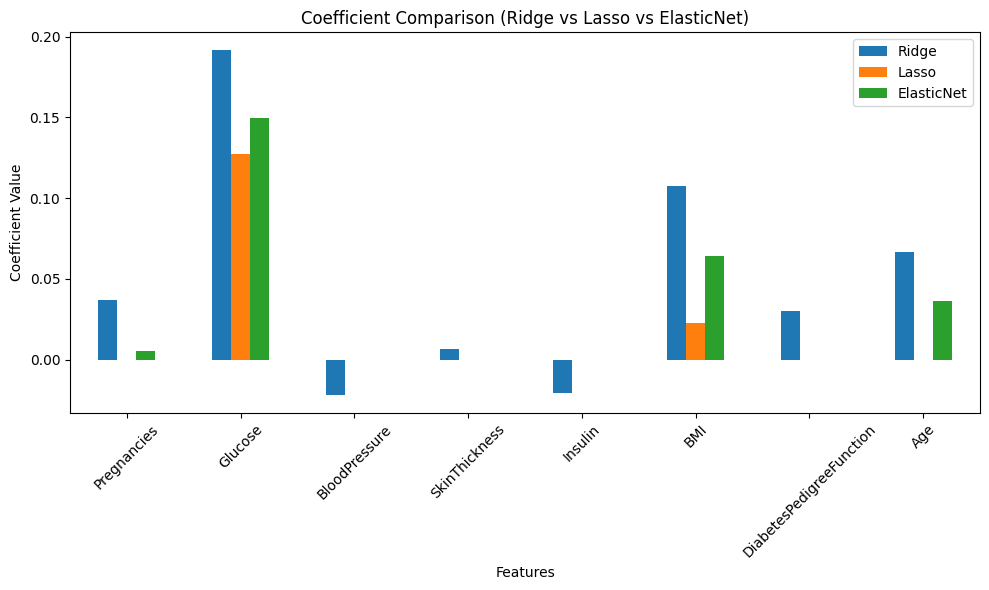

In [21]:
import matplotlib.pyplot as plt

# Set feature as index
coeff_df.set_index('Feature', inplace=True)

# Plot
coeff_df.plot(kind='bar', figsize=(10,6))

plt.title("Coefficient Comparison (Ridge vs Lasso vs ElasticNet)")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Ridge → All bars present (no feature removed)
Lasso → Some bars become 0 (feature removed)
ElasticNet → Mix of both

In this study, the diabetes dataset was preprocessed by handling missing values and analyzing its statistical properties through exploratory data analysis. Regularization techniques including Ridge, Lasso, and ElasticNet regression were applied to improve model performance and reduce overfitting.

The results showed that Ridge regression retained all features while reducing their impact, Lasso regression performed feature selection by shrinking some coefficients to zero, and ElasticNet provided a balance between both methods. The coefficient comparison and visualization clearly demonstrated the effect of regularization on feature importance.

Overall, regularization techniques proved effective in improving model generalization and identifying significant features influencing diabetes prediction.